### Package installation and import 

In [ ]:
#!/bin/bash 
source visualization-env/bin/activate
conda install -c conda-forge basemap
conda install -c conda-forge basemap-data-hires 

In [9]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests
from mpl_toolkits.basemap import Basemap

### Data import & processing

I will use data from https://data.ontario.ca/dataset/bumble-bee-diversity-and-abundance-survey 

This was a survey to determine the abundance and diversity of bumblebees in southwestern Ontario. 

In total, 14 species of bumblebees across various counties in Ontario were collected.  

Data includes site location (county, site #, latitude, longitude, site type); time of collection (year, date); bees collected for each species (queens, workers, males, total); and flowers (flowers nearby, flowers on which bees were found)


In [ ]:
bb_data = pd.read_csv('./raw_data.csv')

#Data Cleaning
##trim trailing spaces in some columns 
bb_data['County'] = bb_data['County'].str.strip() 
bb_data['Lat'] = bb_data['Lat'].str.strip()
bb_data['Long'] = bb_data['Long'].str.strip()

##remove rows with NA values 
bb_data = bb_data.dropna(subset=['County', 'Long']) 

#there is one data input in this dataset: the sign for longitude for site #59 is flipped. correct it here 
bb_data.loc[bb_data['MECP Site Number'] == 59, 'Long'] = -81.081566
bb_data.loc[bb_data['MECP Site Number'] == 59, 'Long']

bb_data

,County,MECP Site Number,Lat,Long,Site Type,Sample date,Year,bimaculatus Queens,bimaculatus workers,bimaculatus males,...,auricomus total,terricola Queens,terricola workers,terricola males,terricola total,flavidus Queens,flavidus males,flavidus total,Flowers in bloom,Flowers Bees Collected on
0,Middlesex,1.0,43.068250,-81.335760,Agricultural,07/02/2015,2015.0,0.0,7.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"birdsfoot trefoil, red clover, white clover, a...","red clover, white clover"
1,Middlesex,2.0,43.107399,-81.284914,Agricultural,08/12/2015,2015.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"teasel, some goldenrod, spotted knapweed, yell...",teasel
2,Essex,3.0,41.987440,-82.531010,Agricultural,05/28/2015,2015.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Dame's violet,purple Dames violet
3,Elgin,4.0,42.870790,-81.113720,Agricultural,06/03/2015,2015.0,0.0,8.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,red clover,red clover
4,Elgin,4.0,42.870790,-81.113720,Agricultural,07/27/2015,2015.0,3.0,8.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"Queen Anne's lace, alfalfa, birdsfoot trefoil,...","red clover, birdsfoot trefoil, knapweed"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
310,Wellington,31.0,43.289690,-79.891800,Semi-natural remnant,08/02/2018,2018.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
311,Wellington,26.0,43.328870,-80.002600,Agricultural,08/09/2018,2018.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
312,Essex,30.0,43.096850,-79.389700,Agricultural,08/15/2018,2018.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
313,Essex,30.0,43.095530,-79.538300,Agricultural,08/15/2018,2018.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN


In [215]:
#Data Processing
##sum total # of bees per species found in each county 
bb_totals = bb_data.groupby('County')[['bimaculatus total', 'griseocollis total', 'impatiens total', 'fervidus total', 'borealis total', 'rufocinctus total', 'pensylvanicus total', 
                                       'vagans total', 'ternarius total', 'perplexus total', 'citrinus total', 'auricomus total', 'terricola total', 'flavidus total']].sum()

##take the average latitude and longitude of the sites in each county to get an approximate map location of counties 
bb_data['Lat'] = pd.to_numeric(bb_data['Lat'])
bb_data['Long'] = pd.to_numeric(bb_data['Long'])
county_coords = bb_data.groupby('County')[['Lat', 'Long']].mean()

#bind the two processed DFs 
county_agg = pd.concat([county_coords, bb_totals], axis=1)

#calculate total number of bees for all species in each county 
county_agg['bee total'] = county_agg.iloc[:, 2:].sum(axis=1)

#change county names from a row index to a column 
county_agg = county_agg.reset_index()

county_agg

,County,Lat,Long,bimaculatus total,griseocollis total,impatiens total,fervidus total,borealis total,rufocinctus total,pensylvanicus total,vagans total,ternarius total,perplexus total,citrinus total,auricomus total,terricola total,flavidus total,bee total
0,Bruce,44.106396,-81.530432,37.0,39.0,48.0,2.0,15.0,27.0,1.0,14.0,0.0,1.0,4.0,0.0,0.0,0.0,188.0
1,Chatham-Kent,42.340787,-81.888912,17.0,76.0,89.0,4.0,0.0,0.0,2.0,53.0,0.0,0.0,34.0,0.0,0.0,0.0,275.0
2,Elgin,42.732024,-81.214508,161.0,46.0,157.0,6.0,2.0,10.0,0.0,37.0,0.0,16.0,7.0,0.0,0.0,0.0,442.0
3,Essex,42.219013,-82.534595,66.0,259.0,394.0,34.0,0.0,8.0,1.0,3.0,0.0,0.0,6.0,0.0,0.0,0.0,771.0
4,Halton,43.289927,-79.876125,14.0,2.0,21.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,38.0
5,Huron,43.765286,-81.679723,170.0,23.0,77.0,0.0,0.0,5.0,0.0,5.0,2.0,3.0,1.0,0.0,0.0,0.0,286.0
6,Lambton,43.043532,-81.983887,33.0,56.0,110.0,6.0,0.0,1.0,0.0,24.0,0.0,0.0,15.0,0.0,0.0,0.0,245.0
7,Middlesex,43.013268,-81.373503,433.0,388.0,521.0,18.0,9.0,43.0,5.0,67.0,2.0,3.0,17.0,0.0,0.0,1.0,1507.0
8,Niagara,43.146820,-79.524154,28.0,20.0,72.0,8.0,6.0,10.0,0.0,14.0,0.0,0.0,1.0,0.0,0.0,0.0,159.0
9,Oxford,43.167058,-80.776220,195.0,44.0,411.0,2.0,1.0,43.0,0.0,16.0,0.0,2.0,5.0,0.0,1.0,0.0,720.0


### Visualization 1

For this visualization I will create a bubble map showing the distribution of bees across 14 Ontario counties.

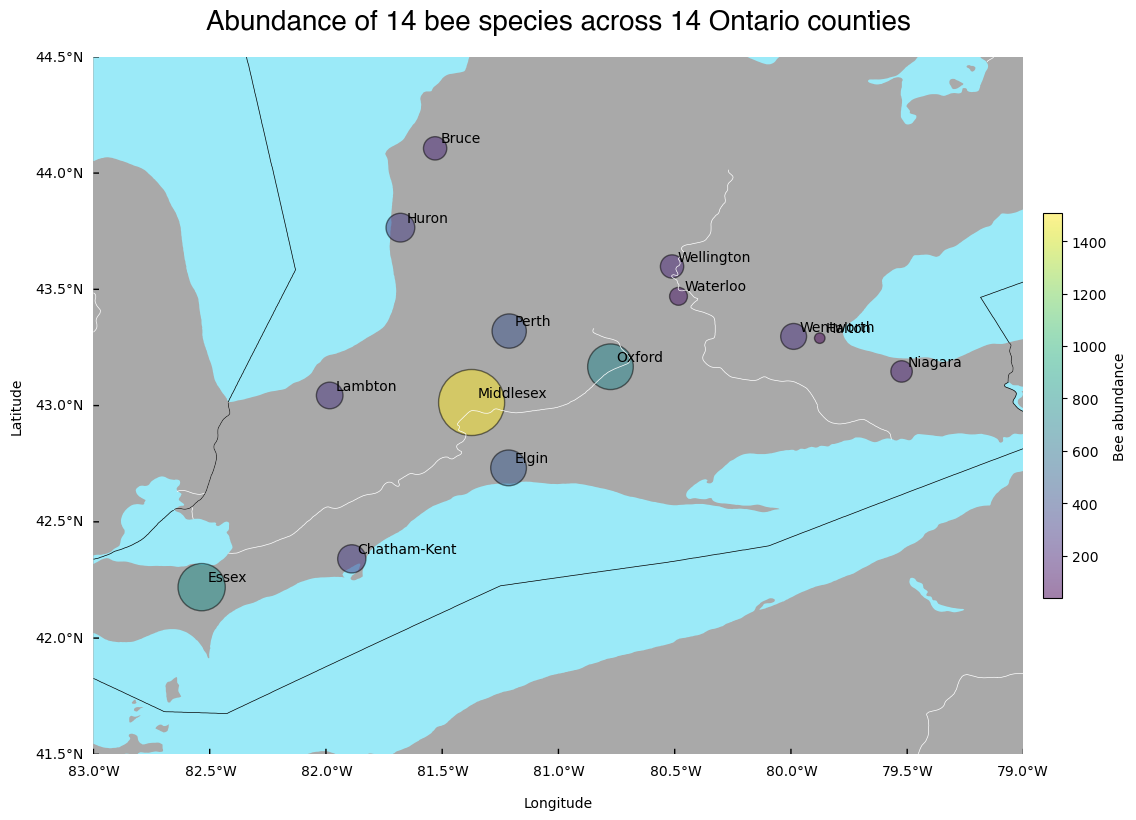

In [228]:
# Define figure size 
plt.figure(figsize=(15, 10))

#Draw a background map
m=Basemap(llcrnrlon=-83, llcrnrlat=41.5,urcrnrlon=-79,urcrnrlat=44.5, #Set the latitude and longitude boundaries to surround the counties
          resolution='f') #use full-resolution map 

# Color map attributes 
m.drawmapboundary(fill_color='black', linewidth=0) #draw map boundary
m.fillcontinents(color='darkgray', lake_color='#9BEAF8') #color land as gray and water as light blue 
m.drawrivers(color = 'white') #draw rivers and color as white 
m.drawcountries() #draw countries (US-Canada border) and color as black

#Overlay bubbles representing total # of bees (across all species) in each county
m.scatter(county_agg['Long'], #use avg longitude and latitude of sample sites as an approximation of that county's coordinates
          county_agg['Lat'], 
          s = county_agg['bee total']*1.5,  #size of bubble is proportional to total number of bees collected in that county 
          alpha = 0.5, #make bubbles semi-transparent
          c = county_agg['bee total'], #color bubbles based on total number of bees as well
          cmap = 'viridis', #use viridis color map 
          linewidth = 1, #add an edge to bubbles 
          edgecolor = 'black') #color edge black 

#Add color bar 
plt.colorbar(shrink = 0.5, anchor = (-0.25, 0.5), #shrink color bar and anchor to right of ax 
             label = 'Bee abundance') #add color bar label 
             

#Add axes labels (lat and long) 
lat_lines = np.arange(41.0, 46.0, 0.5) #define range of latitude labels. set interval of tick marks to 1
long_lines = np.arange(-83.0, -74.0, 0.5)
m.drawparallels(lat_lines, 
                labels=[1, 0, 0, 0], #apply latitude labels only to left side of figure
                textcolor='black', 
                fmt = '%.1f', #force all labels to display 1 decimal place
                dashes=[4,9900]) #workaround for removing gridlines (which interfere with reading the map)
m.drawmeridians(long_lines, labels=[0, 0, 0, 1], textcolor='black', fmt = '%.1f', dashes=[4,9900]) #apply longitutde labels only to bottom of figure


#add plot title and axes labels
font1 = {'family': 'helvetica', 'color': 'black', 'weight': 'bold', 'size': 20} #Define font dict
plt.title('Abundance of 14 bee species across 14 Ontario counties', fontdict = font1, pad = 20) #apply font dict to title
plt.ylabel('Latitude', labelpad = 50) 
plt.xlabel('Longitude', labelpad = 30)

#add county names as annotations 
for county, lat, long in zip(county_agg['County'], county_agg['Lat'], county_agg['Long']): #iterate thru dataset to retrieve county name and map coordinates
    x, y = m(long, lat) 
    plt.annotate(county, xy = (x, y), xytext = (x+0.025, y+0.025)) #specify coordinates of the annotations 

plt.savefig('./viz_1.png', dpi=300) #save figure 

plt.show()
